In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.io import imread
from skimage.filters import threshold_otsu, gaussian
from skimage.morphology import (
    remove_small_objects,
    remove_small_holes,
    binary_closing,
    binary_opening,
    binary_dilation,
)


def rle_decode(rle_mask):
    """
    rle_mask: run-length as string formatted (start length)
    Returns a 101x101 binary mask (1 - salt, 0 - background)
    """
    s = rle_mask.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(101 * 101, dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(101, 101)


def rle_encode(im):
    """
    im: numpy array, 1 - mask, 0 - background
    Returns run length as a space‑delimited string
    """
    pixels = im.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)


def crf(original_image, mask_img):
    """
    Placeholder for the original CRF logic.
    Returns the mask unchanged (binary mask expected).
    """
    if mask_img.ndim == 2:
        return mask_img
    return mask_img[:, :, 0]


def postprocess(mask, min_size=15, closing_size=11):
    """
    Morphological cleaning (lightly tuned):
    - remove objects smaller than `min_size`
    - fill small holes (area_threshold = min_size)
    - close gaps with a square footprint of `closing_size`
    - open to eliminate isolated noise
    - (no dilation) to avoid creating spurious connections
    """
    mask_bool = mask.astype(bool)
    mask_bool = remove_small_objects(mask_bool, min_size=min_size)
    mask_bool = remove_small_holes(mask_bool, area_threshold=min_size)
    footprint = np.ones((closing_size, closing_size), dtype=bool)
    mask_bool = binary_closing(mask_bool, footprint=footprint)
    mask_bool = binary_opening(mask_bool, footprint=footprint)
    return mask_bool.astype(np.uint8)




In [2]:
test_image_dir = "../input/tgs-salt-identification-challenge/test/images/"

test_files = sorted(
    [f for f in os.listdir(test_image_dir) if f.lower().endswith(".png")]
)
test_ids = [os.path.splitext(f)[0] for f in test_files]

df = pd.DataFrame({"id": test_ids, "rle_mask": ""})




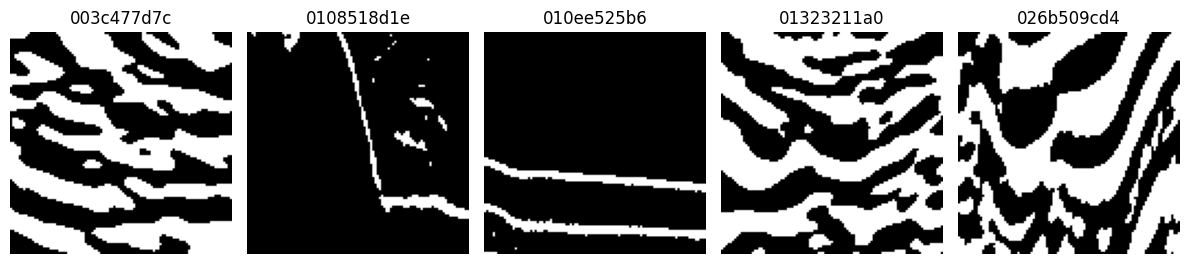

In [3]:
plt.figure(figsize=(12, 4))
for idx in range(min(5, len(df))):
    img_path = os.path.join(test_image_dir, f"{df.loc[idx, 'id']}.png")
    img = imread(img_path)
    if img.ndim == 3:
        img = img.mean(axis=2)  # simple grayscale conversion
    thresh = threshold_otsu(img)
    mask = (img > thresh).astype(np.uint8)
    plt.subplot(1, 5, idx + 1)
    plt.imshow(mask, cmap="gray")
    plt.title(df.loc[idx, "id"])
    plt.axis("off")
plt.tight_layout()
plt.show()




In [4]:
for i in tqdm(range(df.shape[0]), desc="Generating predictions"):
    img_path = os.path.join(test_image_dir, f"{df.loc[i, 'id']}.png")
    img = imread(img_path)
    if img.ndim == 3:
        img = img.mean(axis=2)  # grayscale

    # Use a slightly larger sigma to keep more salt detail while smoothing noise
    img_smooth = gaussian(img, sigma=1.0)

    otsu_thr = threshold_otsu(img_smooth)
    mean_thr = img_smooth.mean()
    median_thr = np.median(img_smooth)

    mask_otsu = img_smooth > otsu_thr
    mask_mean = img_smooth > mean_thr
    mask_median = img_smooth > median_thr

    # Inclusive OR ensemble to boost recall
    combined_mask = (mask_otsu | mask_mean | mask_median).astype(np.uint8)

    combined_mask = crf(None, combined_mask)

    refined_mask = postprocess(combined_mask, min_size=15, closing_size=11)

    df.loc[i, "rle_mask"] = rle_encode(refined_mask)




Generating predictions: 100%|██████████| 1000/1000 [00:04<00:00, 249.06it/s]


In [5]:
df.to_csv("crf_correction.csv", index=False)